# TP1 — Black Friday Sales Prediction
## Análisis y visualización de datos

**Objetivo del negocio:** predecir el monto de compra (`Purchase`) de un cliente para distintos productos, para poder armar ofertas personalizadas.

1. Conocer el dataset (qué columnas hay, calidad de datos, variable objetivo)
2. Explorar y visualizar patrones de compra
3. Extraer conclusiones útiles para un futuro modelo predictivo



# 0. Preparación del entorno

Importamos las librerías y configuramos gráficos legibles.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de gráficos
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('Librerías listas')


Librerías listas


# 1. Familiarización con el dataset

## 1.a Datos disponibles
Importar y analizar el dataset para determinar con qué datos contamos, tanto en cantidad como en calidad.

- Indagar el tipo de cada dato (categórico, numérico).
- Analizar la naturaleza de las variables (demográficas, geográficas, producto, comportamiento de compra).


In [ ]:
# Clonar el repositorio
!git clone https://github.com/dyvanoff/blackfriday_sales_prediction

fatal: destination path 'blackfriday_sales_prediction' already exists and is not an empty directory.


In [ ]:
!ls

blackfriday_sales_prediction  sample_data


In [ ]:
!ls "blackfriday_sales_prediction/datos"

bf_dataset.csv


In [ ]:
df = pd.read_csv("blackfriday_sales_prediction/datos/bf_dataset.csv")

In [ ]:
# Tipos de datos y valores únicos (ayuda a clasificar variables)
info = pd.DataFrame({
    'tipo_pandas': df.dtypes.astype(str),
    'nulos': df.isnull().sum(),
    '% nulos': (df.isnull().mean() * 100).round(2),
    'valores_unicos': df.nunique()
})
info


,tipo_pandas,nulos,% nulos,valores_unicos
User_ID,int64,0,0.00,5891
Product_ID,object,0,0.00,3631
Gender,object,0,0.00,2
Age,object,0,0.00,7
Occupation,int64,0,0.00,21
City_Category,object,0,0.00,3
Stay_In_Current_City_Years,object,0,0.00,5
Marital_Status,int64,0,0.00,2
Product_Category_1,int64,0,0.00,20
Product_Category_2,float64,173638,31.57,17


**Clasificación simple de las variables**

| Variable | Tipo | Naturaleza |
|----------|------|------------|
| `User_ID` | Identificador | Cliente |
| `Product_ID` | Identificador / categórica | Producto |
| `Gender` | Categórica | Demográfica |
| `Age` | Categórica ordinal (rangos) | Demográfica |
| `Occupation` | Categórica (enmascarada) | Demográfica |
| `City_Category` | Categórica | Geográfica |
| `Stay_In_Current_City_Years` | Categórica ordinal | Demográfica / residencia |
| `Marital_Status` | Categórica (0/1) | Demográfica |
| `Product_Category_1/2/3` | Categóricas (enmascaradas) | Producto |
| `Purchase` | Numérica continua | Comportamiento de compra (**objetivo**) |

Contamos con ~550 mil compras, datos demográficos del cliente, categoría de ciudad y categorías de producto. La calidad es buena en casi todas las columnas; los faltantes se concentran en categorías secundarias del producto.


## 1.b Identificación de clientes

- ¿Tenemos forma de identificar de manera única a cada cliente?
- ¿Cuántos clientes únicos tenemos en el dataset?


In [ ]:
n_usuarios = df['User_ID'].nunique()
n_filas = len(df)
compras_por_usuario = df.groupby('User_ID').size()

print(f'Clientes únicos (User_ID): {n_usuarios:,}')
print(f'Transacciones (filas): {n_filas:,}')
print(f'Promedio de productos comprados por cliente: {compras_por_usuario.mean():.1f}')
print(f'Mínimo / máximo de compras por cliente: {compras_por_usuario.min()} / {compras_por_usuario.max()}')
print()
print('¿User_ID identifica al cliente?', 'Sí' if df['User_ID'].notna().all() else 'No')


Clientes únicos (User_ID): 5,891
Transacciones (filas): 550,068
Promedio de productos comprados por cliente: 93.4
Mínimo / máximo de compras por cliente: 6 / 1026

¿User_ID identifica al cliente? Sí


 Sí, `User_ID` identifica al cliente. Hay **5.891 clientes únicos**. Cada fila no es un cliente, sino una **compra de un producto** por un cliente: por eso hay muchas más filas que usuarios.


## 1.c Información temporal

- ¿Tenemos información temporal en el dataset?
- En caso de contar o no con fechas:
  - ¿qué implicancias tiene para el análisis?;
  - ¿qué limitaciones introduce?


In [ ]:
columnas = df.columns.tolist()
posibles_fechas = [c for c in columnas if any(k in c.lower() for k in ['date', 'time', 'day', 'month', 'year', 'fecha', 'hora'])]
print('Columnas del dataset:', columnas)
print('Columnas con apariencia temporal:', posibles_fechas if posibles_fechas else 'Ninguna')


Columnas del dataset: ['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']
Columnas con apariencia temporal: ['Stay_In_Current_City_Years']


 **No hay información temporal** (ni fecha ni hora de compra).

Implicancias y limitaciones:
- No podemos analizar tendencias, estacionalidad ni cambios antes/después de una promoción.
- El análisis es una **foto** de un evento puntual de Black-Friday, no una serie de tiempo.
- Para predecir, el modelo usará perfil del cliente + producto, no el momento de la compra.


## 1.d Datos nulos y suficiencia

- ¿Tenemos datos nulos?
- ¿En qué variables aparecen?
- ¿Qué interpretación de negocio podrían tener?
- ¿Tenemos datos suficientes para pensar en realizar un modelo predictivo?


In [ ]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
pct = (df.isnull().mean() * 100).round(2)
pct = pct[pct > 0].sort_values(ascending=False)

resumen_nulos = pd.DataFrame({'nulos': nulos, '%': pct})
print('Variables con nulos:')
display(resumen_nulos)

# cuantos productos tienen 1, 2 o 3 categorías?
solo_cat1 = df['Product_Category_2'].isna() & df['Product_Category_3'].isna()
cat1_y_2 = df['Product_Category_2'].notna() & df['Product_Category_3'].isna()
tres_cats = df['Product_Category_2'].notna() & df['Product_Category_3'].notna()

print(f'Solo categoría 1: {solo_cat1.sum():,}  ({solo_cat1.mean()*100:.1f}%)')
print(f'Categorías 1 y 2: {cat1_y_2.sum():,}  ({cat1_y_2.mean()*100:.1f}%)')
print(f'Tres categorías:  {tres_cats.sum():,}  ({tres_cats.mean()*100:.1f}%)')
print()
print(f'Tamaño de muestra para modelar: {len(df):,} filas, {df["User_ID"].nunique():,} clientes, variable objetivo sin nulos.')


Variables con nulos:


,nulos,%
Product_Category_3,383247,69.67
Product_Category_2,173638,31.57


Solo categoría 1: 173,638  (31.6%)
Categorías 1 y 2: 209,609  (38.1%)
Tres categorías:  166,821  (30.3%)

Tamaño de muestra para modelar: 550,068 filas, 5,891 clientes, variable objetivo sin nulos.


- Hay nulos en `Product_Category_2` (31.6%) y `Product_Category_3` (69.7%).
- Interpretación de negocio: muchos productos **no tienen segunda/tercera categoría** (no aplica o no está cargada), no necesariamente error.
- Sí hay datos suficientes para un modelo: medio millón de filas, objetivo completo (`Purchase` sin nulos) y multiples variables predictoras.


## 1.e Variable objetivo
- ¿Tenemos la columna objetivo necesaria para un problema de aprendizaje supervisado?
- ¿Qué representa esta variable desde el punto de vista del negocio?

In [ ]:
print('¿Existe la columna Purchase?', 'Purchase' in df.columns)
print('Nulos en Purchase:', df['Purchase'].isnull().sum())
print()
print(df['Purchase'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))


¿Existe la columna Purchase? True
Nulos en Purchase: 0

count   550,068.00
mean      9,263.97
std       5,023.07
min          12.00
25%       5,823.00
50%       8,047.00
75%      12,054.00
90%      16,317.00
95%      19,336.00
99%      20,665.00
max      23,961.00
Name: Purchase, dtype: float64


 Sí hay variable objetivo para aprendizaje supervisado: **`Purchase`** = monto de compra de esa transacción (cliente × producto).Al no haber datos faltantes en la variable objetivo,todos los registros pueden utilizarse para entrenar el modelo sin necesidad de eliminar observaciones.
Desde el negocio, es lo que queremos predecir para personalizar ofertas.
A partir de esta variable podremos ver:
* Perfiles que realizan compras de mayor valor.
* Categorias que generan mayores ingreso.
* Como influye en la compra la variable edad, género incluso la ocupacion en el gasto realizado.
* Cuánto gastará el cliente antes de la compra.



---
# 2. Análisis y visualización de los datos

## 2.a Resumen estadístico (variables numéricas)
Para los datos numéricos, realizar una breve descripción mediante estadísticas de resumen:

- mínimo;
- máximo;
- media;
- mediana;
- cuantiles

In [ ]:
# Aunque Occupation y categorías son códigos, las incluimos porque son numéricas en el archivo.
numericas = ['Occupation', 'Marital_Status', 'Product_Category_1',
             'Product_Category_2', 'Product_Category_3', 'Purchase']

resumen = df[numericas].describe(percentiles=[0.25, 0.5, 0.75]).T
resumen['mediana'] = df[numericas].median()
resumen[['min', '25%', 'mediana', '50%', 'mean', '75%', 'max']]


,min,25%,mediana,50%,mean,75%,max
Occupation,0.00,2.00,7.00,7.00,8.08,14.00,20.00
Marital_Status,0.00,0.00,0.00,0.00,0.41,1.00,1.00
Product_Category_1,1.00,1.00,5.00,5.00,5.40,8.00,20.00
Product_Category_2,2.00,5.00,9.00,9.00,9.84,15.00,18.00
Product_Category_3,3.00,9.00,14.00,14.00,12.67,16.00,18.00
Purchase,12.00,"5,823.00","8,047.00","8,047.00","9,263.97","12,054.00","23,961.00"


El gasto (`Purchase`) va de 12 a 23.961, con media $\sim$9.264 y mediana $\sim$ 8.047. Como la media > mediana, ya sospechamos **ligera asimetría a la derecha** (algunas compras altas empujan el promedio).


## 2.b Distribución de variables (histogramas y boxplots)


### Atributo `Purchase`

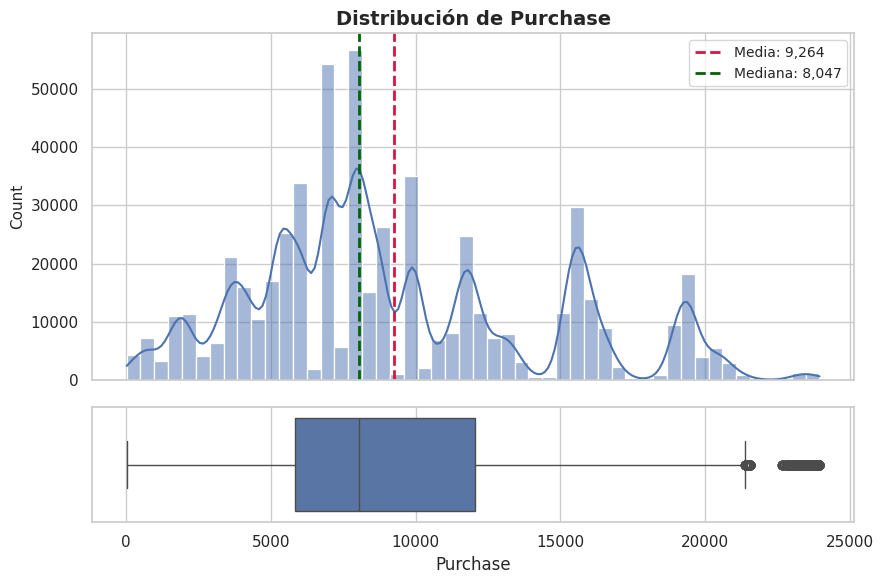

In [ ]:
fig, (ax_hist, ax_box) = plt.subplots(
    2, 1,
    figsize=(9, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(df['Purchase'], bins=50, kde=True, color="#4C72B0", ax=ax_hist)
ax_hist.set_title("Distribución de Purchase", fontsize=14, fontweight="bold")
ax_hist.set_xlabel("")

media = df['Purchase'].mean()
mediana = df['Purchase'].median()

ax_hist.axvline(media, color="crimson", linestyle="--", linewidth=2,
                 label=f"Media: {media:,.0f}")
ax_hist.axvline(mediana, color="darkgreen", linestyle="--", linewidth=2,
                 label=f"Mediana: {mediana:,.0f}")

ax_hist.legend(fontsize=10)

sns.boxplot(x=df['Purchase'], color="#4C72B0", ax=ax_box)
ax_box.set_xlabel("Purchase", fontsize=12)

plt.tight_layout()
plt.show()


La distribución de `Purchase` es multimodal, con varios picos bien diferenciados en lugar de una única campana. Esto probablemente se deba a que distintas categorías de producto tienen rangos de precio característicos, hipótesis que se puede confirmar coloreando el histograma por `Product_Category_1` (queda para un análisis posterior).

Los valores que el boxplot marca como outliers se ubican en la cola superior de la distribución. Sin embargo, no se trata de errores de carga: son transacciones reales de montos altos, por lo que no corresponde eliminarlos del análisis.

### Atributo `Gender`

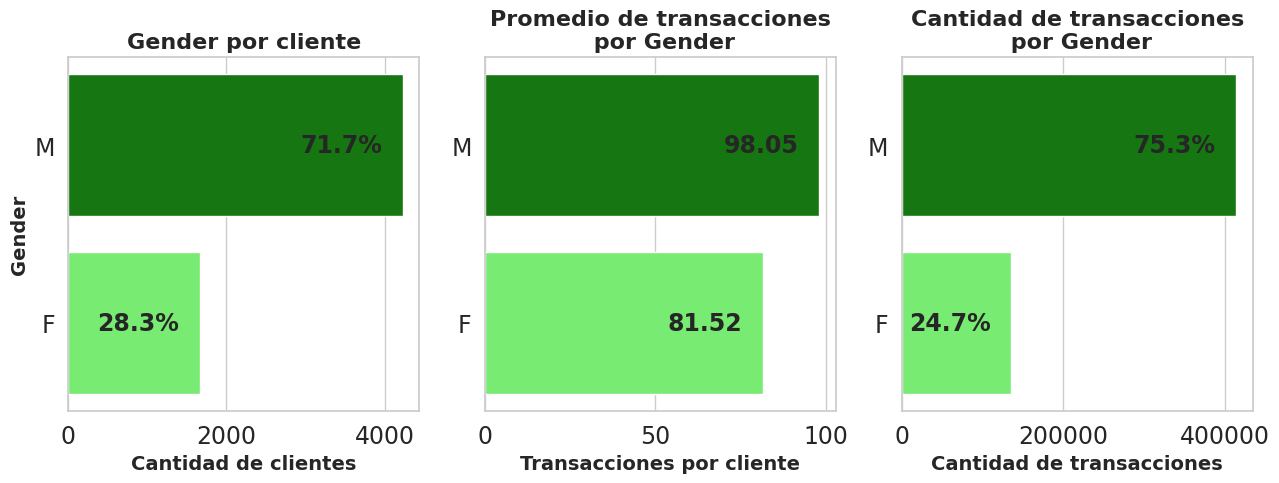

In [ ]:
usuarios_unicos = df.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

palette_gender = {'M': "#078700", 'F': "#66FF5E"}

# Panel 1: por cliente único
sns.countplot(y='Gender', data=usuarios_unicos,
              order=usuarios_unicos['Gender'].value_counts().index,
              ax=axes[0],
              hue='Gender',
              palette=palette_gender,
              legend=False)
axes[0].set_title('Gender por cliente', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=17)

total_usuarios = len(usuarios_unicos)
for p in axes[0].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_usuarios) * 100:.1f}%'
    axes[0].annotate(
        porcentaje,
        (ancho, p.get_y() + p.get_height() / 2.0),
        ha='right', va='center',
        xytext=(-15, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )

# Panel 2: transacciones promedio por género
tx_por_cliente = (
    df.groupby(['User_ID', 'Gender']).size().reset_index(name='Transacciones')
)
promedio_tx = (
    tx_por_cliente.groupby('Gender')['Transacciones'].mean().reset_index()
)
sns.barplot(
    y='Gender', x='Transacciones', data=promedio_tx,
    order=promedio_tx.sort_values(by='Transacciones', ascending=False)['Gender'],
    ax=axes[1], hue='Gender', palette=palette_gender,
    orient='h', legend=False,
)
axes[1].set_title('Promedio de transacciones\n por Gender', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Transacciones por cliente', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].tick_params(axis='both', labelsize=17)

for p in axes[1].patches:
    ancho = p.get_width()
    axes[1].annotate(
        f'{ancho:.2f}',
        (ancho, p.get_y() + p.get_height() / 2.0),
        ha='right', va='center',
        xytext=(-15, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )

# Panel 3: por transacción
sns.countplot(y='Gender', data=df,
              order=df['Gender'].value_counts().index,
              ax=axes[2], hue='Gender', palette=palette_gender,
              legend=False)
axes[2].set_title('Cantidad de transacciones\n por Gender', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Cantidad de transacciones', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')
axes[2].tick_params(axis='both', labelsize=17)

total_transacciones = len(df)
for p in axes[2].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_transacciones) * 100:.1f}%'
    axes[2].annotate(
        porcentaje,
        (ancho, p.get_y() + p.get_height() / 2.0),
        ha='right', va='center',
        xytext=(-15, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )

plt.tight_layout()
plt.show()


Haciendo un análisis del `Gender` de los clientes vemos que hay un mayor número de Hombres ($\sim$72%) que de Mujeres ($\sim$28%).

Asimismo, se observa que los hombres realizan, en promedio, un $\sim$20% más de transacciones por cliente que las mujeres (98.05 vs. 81.52), lo cual explica por qué su participación en el total de transacciones (75.3%) es mayor a su participación en la base de clientes (71.7%).

La diferencia no es grande, pero existe. Más adelante evaluaremos el dinero generado por cada transacción según el género, y si esta diferencia tiene algún impacto.

### Atributo `Age`

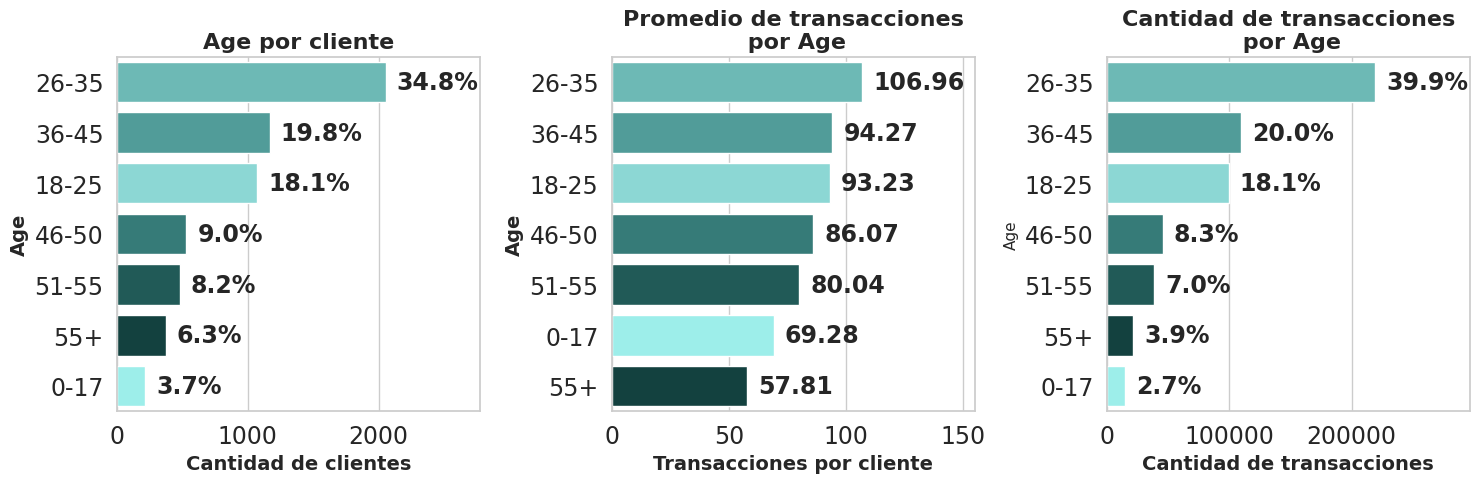

In [ ]:
usuarios_unicos = df.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette_age = {
    '0-17': '#90fbf6',
    '18-25': '#7fe4df',
    '26-35': '#60c6c1',
    '36-45': '#44a9a4',
    '46-50': '#2a8782',
    '51-55': '#176460',
    '55+': '#0b4946'
    }

# Panel 1: por cliente único
sns.countplot(y='Age', data=usuarios_unicos,
              order=usuarios_unicos['Age'].value_counts().index,
              ax=axes[0], hue='Age', palette=palette_age, legend=False)
axes[0].set_title('Age por cliente', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Age', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=17)

total_usuarios = len(usuarios_unicos)
for p in axes[0].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_usuarios) * 100:.1f}%'
    axes[0].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[0].set_xlim(0, usuarios_unicos['Age'].value_counts().max() * 1.35)

# Panel 2: transacciones promedio por Age
tx_por_cliente = (
    df.groupby(['User_ID', 'Age']).size().reset_index(name='Transacciones')
)
promedio_tx = (
    tx_por_cliente.groupby('Age')['Transacciones'].mean().reset_index()
)
sns.barplot(
    y='Age', x='Transacciones', data=promedio_tx,
    order=promedio_tx.sort_values(by='Transacciones', ascending=False)['Age'],
    ax=axes[1], hue='Age', palette=palette_age, orient='h', legend=False,
)
axes[1].set_title('Promedio de transacciones\n por Age', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Age', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='y', left=False)
axes[1].set_xlabel('Transacciones por cliente', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=17)

for p in axes[1].patches:
    ancho = p.get_width()
    axes[1].annotate(
        f'{ancho:.2f}', (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[1].set_xlim(0, promedio_tx['Transacciones'].max() * 1.45)

# Panel 3: por transacción
sns.countplot(y='Age', data=df,
              order=df['Age'].value_counts().index,
              ax=axes[2], hue='Age', palette=palette_age, legend=False)
axes[2].set_title('Cantidad de transacciones\n por Age', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Age', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='y', left=False)
axes[2].set_xlabel('Cantidad de transacciones', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='both', labelsize=17)

total_transacciones = len(df)
for p in axes[2].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_transacciones) * 100:.1f}%'
    axes[2].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[2].set_xlim(0, df['Age'].value_counts().max() * 1.35)



plt.tight_layout()
plt.show()

Analizando Age vemos que el grupo etario con mayor de clientes es 26 y 35 años, representando $∼$35% del total, y los menos representados son los de 0-17 años, solo el $\sim$ 4%. Vemos también que el mayor promedio de transacciones también lo tienen los clientes de 26 a 35 años. El promedio entre los clientes de 36 a 45 es muy similar al de 18 a 25, aunque los primeros tienen 1 compra más ($∼$94 a $∼$93). Pero, a diferencia de la cantidad de clientes por edad, vemos que aquí los de 55+ (el $∼$6% de los clientes) son los que menos transacciones hacen ($∼$58), mientras que los de 0 a 17 años realizan en promedio $∼$69 transacciones. Por último, vemos que el orden de representación entre grupos etarios se mantiene igual al comparar cantidad de clientes y cantidad de transacciones — el ranking de los siete grupos no cambia — aunque las proporciones sí se corren: los grupos con mayor promedio de transacciones (como 26-35) ganan peso relativo en el total de transacciones respecto a su peso en la base de clientes.

### Atributo ``City_Category``

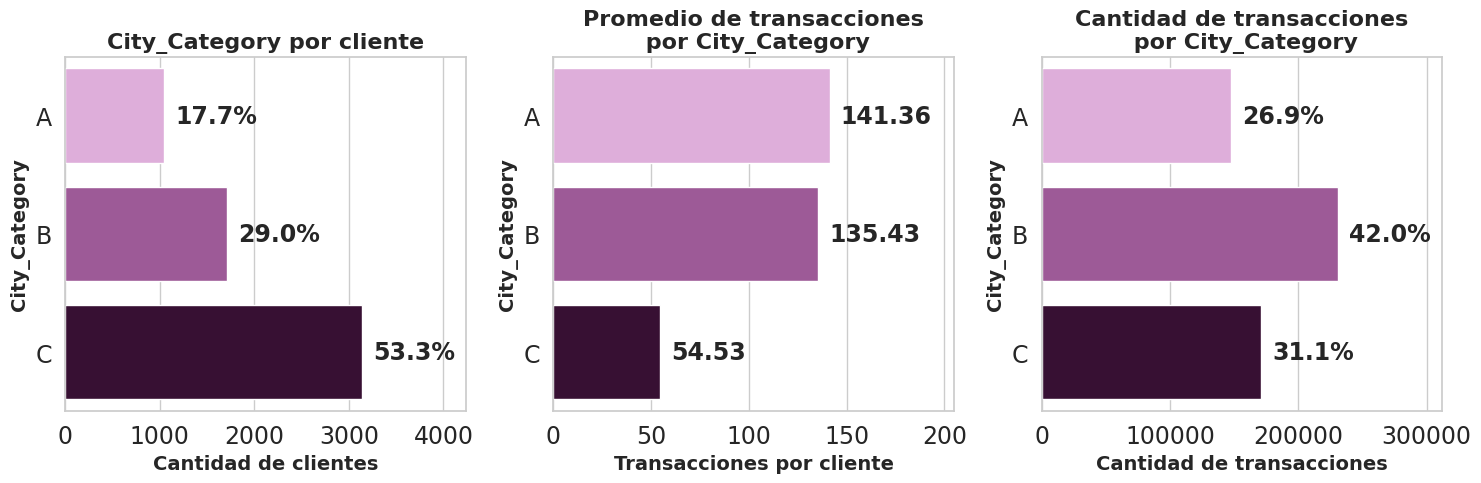

In [ ]:
usuarios_unicos = df.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette_city = {
    'A': '#e6a6e0',
    'B': '#a84fa0',
    'C': '#3d0a38'
    }

# Panel 1: por cliente único
sns.countplot(y='City_Category', data=usuarios_unicos,
              order=['A', 'B', 'C'],
              ax=axes[0], hue='City_Category', palette=palette_city, legend=False)
axes[0].set_title('City_Category por cliente', fontsize=16, fontweight='bold')
axes[0].set_ylabel('City_Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=17)

total_usuarios = len(usuarios_unicos)
for p in axes[0].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_usuarios) * 100:.1f}%'
    axes[0].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[0].set_xlim(0, usuarios_unicos['City_Category'].value_counts().max() * 1.35)

# Panel 2: transacciones promedio por City_Category
tx_por_cliente = (
    df.groupby(['User_ID', 'City_Category']).size().reset_index(name='Transacciones')
)
promedio_tx = (
    tx_por_cliente.groupby('City_Category')['Transacciones'].mean().reset_index()
)
sns.barplot(
    y='City_Category', x='Transacciones', data=promedio_tx,
    order=promedio_tx.sort_values(by='Transacciones', ascending=False)['City_Category'],
    ax=axes[1], hue='City_Category', palette=palette_city, orient='h', legend=False,
)
axes[1].set_title('Promedio de transacciones\n por City_Category', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Transacciones por cliente', fontsize=14, fontweight='bold')
axes[1].set_ylabel('City_Category', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=17)

for p in axes[1].patches:
    ancho = p.get_width()
    axes[1].annotate(
        f'{ancho:.2f}', (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[1].set_xlim(0, promedio_tx['Transacciones'].max() * 1.45)

# Panel 3: por transacción
sns.countplot(y='City_Category', data=df,
              order=['A', 'B', 'C'],
              ax=axes[2], hue='City_Category', palette=palette_city, legend=False)
axes[2].set_title('Cantidad de transacciones\n por City_Category', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Cantidad de transacciones', fontsize=14, fontweight='bold')
axes[2].set_ylabel('City_Category', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='both', labelsize=17)

total_transacciones = len(df)
for p in axes[2].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_transacciones) * 100:.1f}%'
    axes[2].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[2].set_xlim(0, df['City_Category'].value_counts().max() * 1.35)

plt.tight_layout()
plt.show()

En el análisis de City_Category vemos que la mayor cantidad de clientes está en la ciudad C (53.3%), seguida por B (29.0%) y A (17.7%). Sin embargo, algo muy interesante es que la ciudad A es la que en promedio realiza la mayor cantidad de transacciones por cliente (141.36), seguida de cerca por B (135.43), y bastante más atrás C (54.53), las ciudades A y B realizan, respectivamente, $\sim$159% y $\sim$148% más transacciones por cliente que C.

Esta combinación de factores opuestos, muchos clientes pero el promedio más bajo de las tres, explica que C no quede última en el total de transacciones (31.1%): su volumen de clientes compensa el bajo promedio individual. B lidera (42.0%) al combinar buena base de clientes con buen promedio, mientras que A, pese a tener el mejor promedio, queda última (26.9%) por ser la ciudad con menos clientes.

### Atributo `Marital_Status`

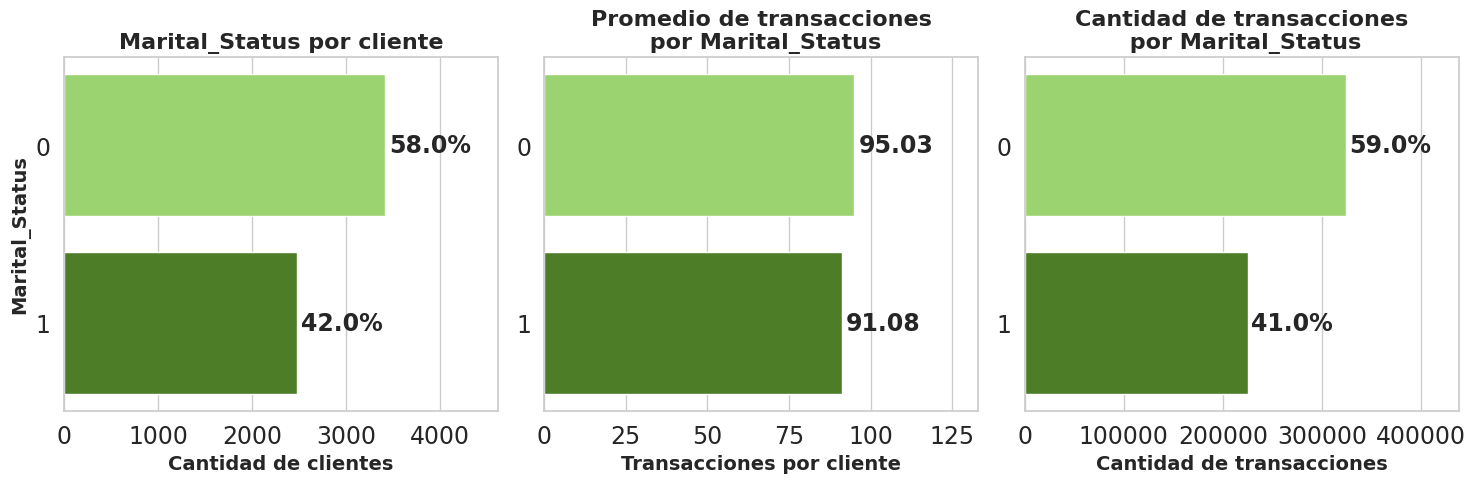

In [ ]:
usuarios_unicos = df.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette_marital = {
    0: '#99e361',
    1: '#4b8d18'
    }

# Panel 1: por cliente único
sns.countplot(y='Marital_Status', data=usuarios_unicos,
              order=usuarios_unicos['Marital_Status'].value_counts().index,
              ax=axes[0], hue='Marital_Status', palette=palette_marital, legend=False)
axes[0].set_title('Marital_Status por cliente', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Marital_Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=17)

total_usuarios = len(usuarios_unicos)
for p in axes[0].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_usuarios) * 100:.1f}%'
    axes[0].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(3, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )

# Panel 2: transacciones promedio por Marital_Status
tx_por_cliente = (
    df.groupby(['User_ID', 'Marital_Status']).size().reset_index(name='Transacciones')
)
promedio_tx = (
    tx_por_cliente.groupby('Marital_Status')['Transacciones'].mean().reset_index()
)
sns.barplot(
    y='Marital_Status', x='Transacciones', data=promedio_tx,
    order=promedio_tx.sort_values(by='Transacciones', ascending=False)['Marital_Status'],
    ax=axes[1], hue='Marital_Status', palette=palette_marital,
    orient='h',  # necesario: ambas columnas son numéricas, sin esto seaborn no dibuja las barras
    legend=False,
)
axes[1].set_title('Promedio de transacciones\n por Marital_Status', fontsize=16, fontweight='bold')
# axes[1].set_ylabel('Marital_Status', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('Transacciones por cliente', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=17)

for p in axes[1].patches:
    ancho = p.get_width()
    axes[1].annotate(
        f'{ancho:.2f}', (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(3, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )

# Panel 3: por transacción
sns.countplot(y='Marital_Status', data=df,
              order=df['Marital_Status'].value_counts().index,
              ax=axes[2], hue='Marital_Status', palette=palette_marital, legend=False)
axes[2].set_title('Cantidad de transacciones\n por Marital_Status', fontsize=16, fontweight='bold')
# axes[2].set_ylabel('Marital_Status', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Cantidad de transacciones', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')
axes[2].tick_params(axis='both', labelsize=17)

total_transacciones = len(df)
for p in axes[2].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_transacciones) * 100:.1f}%'
    axes[2].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(2, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )

# Panel 1
axes[0].set_xlim(0, usuarios_unicos['Marital_Status'].value_counts().max() * 1.35)
# Panel 2
axes[1].set_xlim(0, promedio_tx['Transacciones'].max() * 1.40)
# Panel 3
axes[2].set_xlim(0, df['Marital_Status'].value_counts().max() * 1.35)

plt.tight_layout()
plt.show()

En el análisis de `Marital_Status` vemos que el grupo 0 es el más numeroso, representando el 58.0% de los clientes frente al 42.0% del grupo 1, una diferencia de 16 puntos porcentuales. Sin embargo, el promedio de transacciones por cliente es muy similar entre ambos grupos (95.03 vs. 91.08), por lo que, a diferencia de lo observado en Gender y `City_Category`, la participación en el total de transacciones prácticamente no se corre respecto a la participación en clientes (58.0%→59.0% y 42.0%→41.0%).

Esto sugiere que, en términos de frecuencia de compra, el estado civil no genera una diferencia relevante de comportamiento entre ambos grupos, algo que sí veíamos con las otras variables analizadas. Queda pendiente para más adelante evaluar si esta similitud se mantiene también en el monto gastado por transacción, o si ahí aparece una diferencia que acá no se observa.

### Atributo `Stay_In_Current_City_Years`

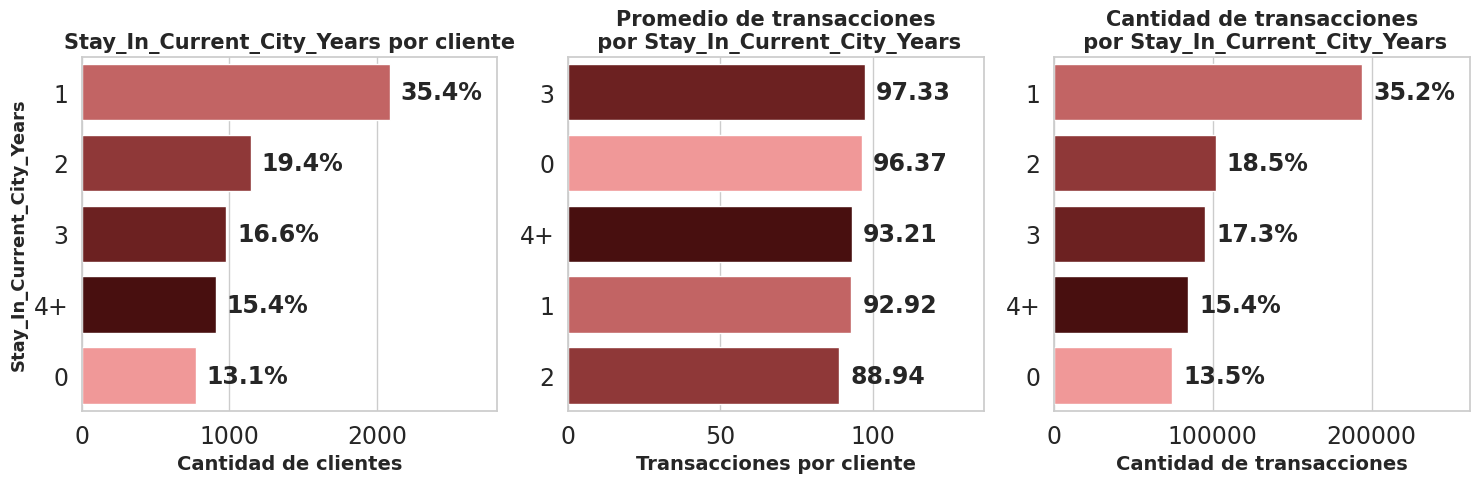

In [ ]:
usuarios_unicos = df.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette_cityyears = {
    '0': '#ff8989',
    '1': '#d15555',
    '2': '#9d2a2a',
    '3': '#781414',
    '4+': '#510606',
    }

# Panel 1: por cliente único
sns.countplot(y='Stay_In_Current_City_Years', data=usuarios_unicos,
              order=usuarios_unicos['Stay_In_Current_City_Years'].value_counts().index,
              ax=axes[0], hue='Stay_In_Current_City_Years', palette=palette_cityyears, legend=False)
axes[0].set_title('Stay_In_Current_City_Years por cliente', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Stay_In_Current_City_Years', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=17)

total_usuarios = len(usuarios_unicos)
for p in axes[0].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_usuarios) * 100:.1f}%'
    axes[0].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[0].set_xlim(0, usuarios_unicos['Stay_In_Current_City_Years'].value_counts().max() * 1.35)

# Panel 2: transacciones promedio por Stay_In_Current_City_Years
tx_por_cliente = (
    df.groupby(['User_ID', 'Stay_In_Current_City_Years']).size().reset_index(name='Transacciones')
)
promedio_tx = (
    tx_por_cliente.groupby('Stay_In_Current_City_Years')['Transacciones'].mean().reset_index()
)
sns.barplot(
    y='Stay_In_Current_City_Years', x='Transacciones', data=promedio_tx,
    order=promedio_tx.sort_values(by='Transacciones', ascending=False)['Stay_In_Current_City_Years'],
    ax=axes[1], hue='Stay_In_Current_City_Years', palette=palette_cityyears, orient='h', legend=False,
)
axes[1].set_title('Promedio de transacciones\n por Stay_In_Current_City_Years', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Transacciones por cliente', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].tick_params(axis='both', labelsize=17)

for p in axes[1].patches:
    ancho = p.get_width()
    axes[1].annotate(
        f'{ancho:.2f}', (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[1].set_xlim(0, promedio_tx['Transacciones'].max() * 1.40)

# Panel 3: por transacción
sns.countplot(y='Stay_In_Current_City_Years', data=df,
              order=df['Stay_In_Current_City_Years'].value_counts().index,
              ax=axes[2], hue='Stay_In_Current_City_Years', palette=palette_cityyears, legend=False)
axes[2].set_title('Cantidad de transacciones\n por Stay_In_Current_City_Years', fontsize=15, fontweight='bold')
axes[2].set_xlabel('Cantidad de transacciones', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')
axes[2].tick_params(axis='both', labelsize=17)

total_transacciones = len(df)
for p in axes[2].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_transacciones) * 100:.1f}%'
    axes[2].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[2].set_xlim(0, df['Stay_In_Current_City_Years'].value_counts().max() * 1.35)

plt.tight_layout()
plt.show()

En el análisis de `Stay_In_Current_City_Years` vemos que la mayoría de los clientes lleva 1 año en su ciudad actual (35.4%), mientras que el grupo menos representado es el de 0 años (recién mudados, 13.1%). A diferencia de lo observado en `Gender`, `Age` y `City_Category`, acá los promedios de transacciones por cliente son muy parecidos entre todos los grupos (entre 88.94 y 97.33, una diferencia relativamente chica), el grupo que más se despega, con el promedio más bajo, es el de 2 años (88.94).

Como resultado de esta similitud entre promedios, el orden de representación se mantiene prácticamente idéntico entre la cantidad de clientes y la cantidad de transacciones (1 > 2 > 3 > 4+ > 0 en ambos casos, con porcentajes casi iguales), el mismo patrón de estabilidad que ya habíamos visto en Marital_Status, donde promedios similares implican que el peso poblacional de cada grupo no se ve amplificado ni compensado por diferencias de comportamiento individual.

### Atributo `Occupation`

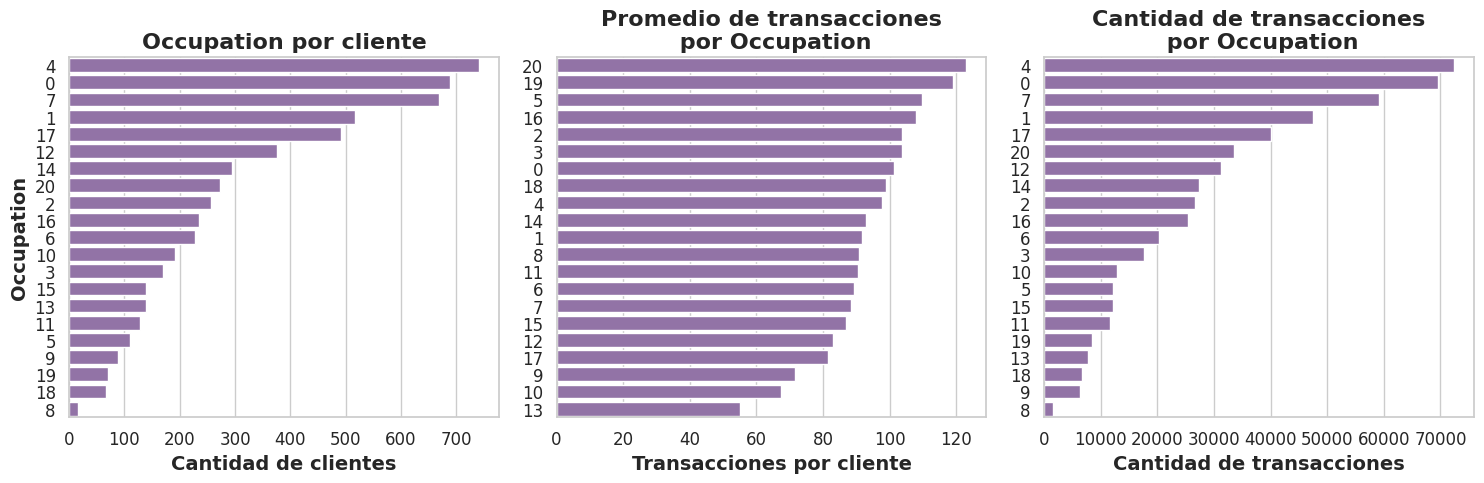

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

codigos_occupation = sorted(df['Occupation'].unique())
palette_occupation = {codigo: '#946BAE' for codigo in codigos_occupation}

# Panel 1: por cliente único
sns.countplot(y='Occupation', data=usuarios_unicos,
              order=usuarios_unicos['Occupation'].value_counts().index,
              ax=axes[0], hue='Occupation', palette=palette_occupation, legend=False)
axes[0].set_title('Occupation por cliente', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Occupation', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=12)

# Panel 2: transacciones promedio por Occupation
tx_por_cliente = (
    df.groupby(['User_ID', 'Occupation']).size().reset_index(name='Transacciones')
)
promedio_tx = (
    tx_por_cliente.groupby('Occupation')['Transacciones'].mean().reset_index()
)
sns.barplot(
    y='Occupation', x='Transacciones', data=promedio_tx,
    order=promedio_tx.sort_values(by='Transacciones', ascending=False)['Occupation'],
    ax=axes[1], hue='Occupation', palette=palette_occupation, orient='h', legend=False,
)
axes[1].set_title('Promedio de transacciones\n por Occupation', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Transacciones por cliente', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].tick_params(axis='both', labelsize=12)

# Panel 3: por transacción
sns.countplot(y='Occupation', data=df,
              order=df['Occupation'].value_counts().index,
              ax=axes[2], hue='Occupation', palette=palette_occupation, legend=False)
axes[2].set_title('Cantidad de transacciones\n por Occupation', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Cantidad de transacciones', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')
axes[2].tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

El análisis de `Occupation` es más complejo por tratarse de 21 categorías sin significado conocido. Aun así, se observa que las cuatro ocupaciones más frecuentes en cantidad de clientes (4, 0, 7 y 1) se mantienen como las cuatro más frecuentes también en cantidad total de transacciones, y la ocupación menos representada (8) sigue siendo la última en ambos rankings, sugiriendo que, en los extremos, el comportamiento es consistente.

Sin embargo, en las posiciones intermedias sí aparecen corrimientos interesantes: la ocupación 20, que es solo la 8va en cantidad de clientes, tiene el promedio de transacciones por cliente más alto de las 21 categorías ($\sim$120), lo cual la impulsa hasta el 6to lugar en cantidad total de transacciones. En el sentido opuesto, la ocupación 13 tiene el promedio más bajo ($\sim$55) y, pese a partir de una posición intermedia en cantidad de clientes, cae varios puestos en el ranking de transacciones totales. Ambos casos son ejemplos del mismo mecanismo de amplificación/compensación que veníamos observando en otras variables: el promedio de transacciones por cliente puede correr a un grupo hacia arriba o hacia abajo en el ranking de volumen total, independientemente de cuántos clientes tenga.

### 2.c Distribución de la variable objetivo `Purchase`


Asimetría (skewness): 0.600
Interpretación: > 0 = cola a la derecha (sesgo positivo)

Percentiles altos (valores extremos):
0.90   16,317.00
0.95   19,336.00
0.99   20,665.00
1.00   23,961.00
Name: Purchase, dtype: float64


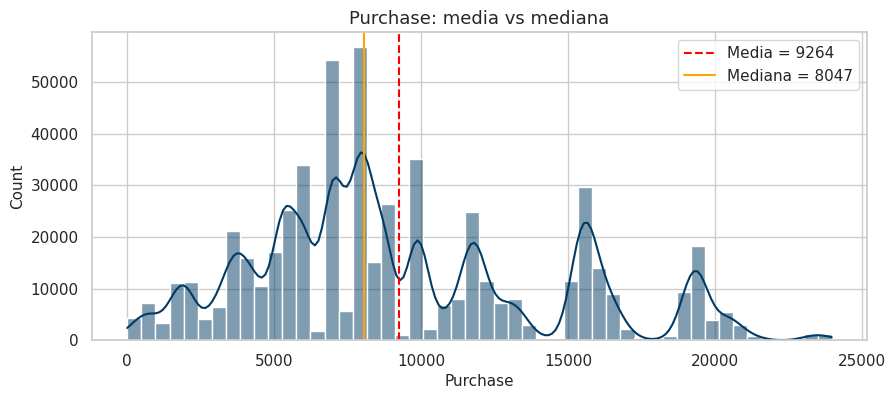

In [ ]:
skewness = df['Purchase'].skew()
print(f'Asimetría (skewness): {skewness:.3f}')
print('Interpretación: > 0 = cola a la derecha (sesgo positivo)')
print()
print('Percentiles altos (valores extremos):')
print(df['Purchase'].quantile([0.9, 0.95, 0.99, 1.0]))

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df['Purchase'], bins=50, kde=True, color='#013a63', ax=ax)
ax.axvline(df['Purchase'].mean(), color='red', linestyle='--', label=f"Media = {df['Purchase'].mean():.0f}")
ax.axvline(df['Purchase'].median(), color='orange', linestyle='-', label=f"Mediana = {df['Purchase'].median():.0f}")
ax.set_title('Purchase: media vs mediana')
ax.legend()
plt.show()


`Purchase` está **ligeramente sesgada a la derecha**. Hay valores extremos (cerca de 20–24 mil), pero el comportamiento general se concentra alrededor de 6–12 mil. El gasto típico (mediana 8.047) es un poco menor que el promedio (~9.264).


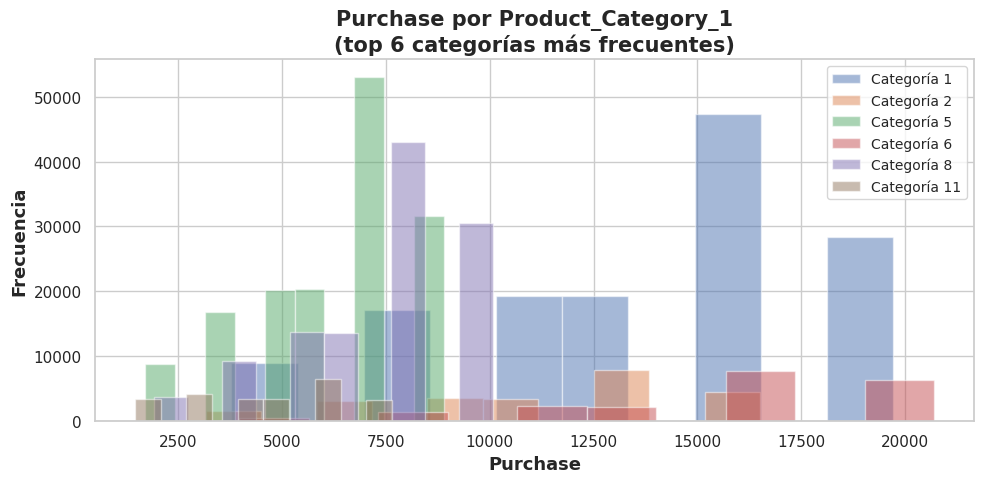

In [ ]:
top_categorias = df['Product_Category_1'].value_counts().head(6).index

fig, ax = plt.subplots(figsize=(10, 5))
for cat in sorted(top_categorias):
    subset = df[df['Product_Category_1'] == cat]['Purchase']
    ax.hist(subset, bins=10, alpha=0.5, label=f'Categoría {cat}')

ax.set_title('Purchase por Product_Category_1\n(top 6 categorías más frecuentes)', fontsize=15, fontweight='bold')
ax.set_xlabel('Purchase', fontsize=13, fontweight='bold')
ax.set_ylabel('Frecuencia', fontsize=13, fontweight='bold')
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

La distribución de `Purchase` es multimodal, con varios picos bien diferenciados en lugar de una única campana. Como se hipotetizó en 2.b, esto se debe a que distintas categorías de producto tienen rangos de precio característicos, lo cual se confirma al colorear el histograma por `Product_Category_1`. Sin embargo, estos rangos no son completamente independientes entre sí: categorías como 5 y 8, o 1, 2 y 6, se superponen parcialmente en su rango de precios. Esta superposición se evalúa con mayor detalle en 2.f.

### 2.d Comparación del comportamiento de compra


#### 1) ¿Cuál es la distribución de los clientes por género?


En el punto 2b) se respondió esta pregunta: 71.7% hombres y 28.3% mujeres, y los hombres representan el 75% de las transacciones. Sin embargo, quedó pendiente relacionar Gender con Purchase, análisis que se realiza a continuación.

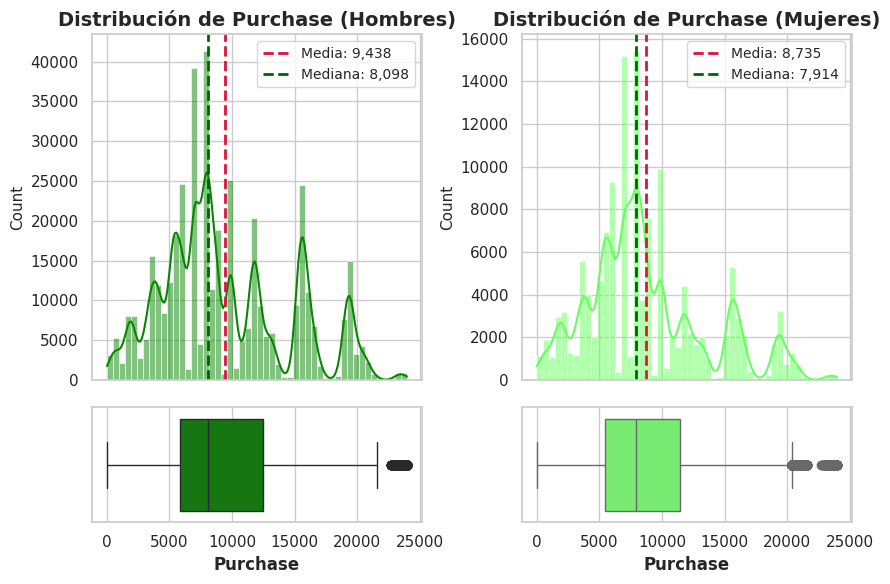

In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(9, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(df[df['Gender']=='M']['Purchase'], bins=50, kde=True, color="#078700", ax=axes[0,0])
axes[0,0].set_title("Distribución de Purchase (Hombres)", fontsize=14, fontweight="bold")
axes[0,0].set_xlabel("")

media = df[df['Gender']=='M']['Purchase'].mean()
mediana = df[df['Gender']=='M']['Purchase'].median()

axes[0,0].axvline(media, color="crimson", linestyle="--", linewidth=2,
                 label=f"Media: {media:,.0f}")
axes[0,0].axvline(mediana, color="darkgreen", linestyle="--", linewidth=2,
                 label=f"Mediana: {mediana:,.0f}")

axes[0,0].legend(fontsize=10)

sns.boxplot(x=df[df['Gender']=='M']['Purchase'], color="#078700", ax=axes[1,0])
axes[1,0].set_xlabel("Purchase", fontsize=12, fontweight="bold")

sns.histplot(df[df['Gender']=='F']['Purchase'], bins=50, kde=True, color="#66FF5E", ax=axes[0,1])
axes[0,1].set_title("Distribución de Purchase (Mujeres)", fontsize=14, fontweight="bold")
axes[0,1].set_xlabel("")

media = df[df['Gender']=='F']['Purchase'].mean()
mediana = df[df['Gender']=='F']['Purchase'].median()

axes[0,1].axvline(media, color="crimson", linestyle="--", linewidth=2,
                 label=f"Media: {media:,.0f}")
axes[0,1].axvline(mediana, color="darkgreen", linestyle="--", linewidth=2,
                 label=f"Mediana: {mediana:,.0f}")

axes[0,1].legend(fontsize=10)

sns.boxplot(x=df[df['Gender']=='F']['Purchase'], color="#66FF5E", ax=axes[1,1])
axes[1,1].set_xlabel("Purchase", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
p90 = df['Purchase'].quantile(0.90)

resultados = []
for genero in ['M', 'F']:
    sub = df[df['Gender'] == genero]
    pct = (sub['Purchase'] > p90).mean() * 100
    resultados.append({'Gender': genero, 'Pct_sobre_P90': pct})

pd.DataFrame(resultados)

,Gender,Pct_sobre_P90
0,M,10.61
1,F,8.13


Comparando la distribución de Purchase entre géneros, la mediana es muy similar entre ambos (8.098 en hombres, 7.914 en mujeres), lo cual indica que el grueso de las compras tiene un monto parecido independientemente del género. Sin embargo, la media es notablemente mayor en hombres (9.438 vs. 8.735), lo cual sugiere que los hombres tienen una cola de compras de montos altos algo más pesada que las mujeres, visible también en el boxplot, donde el grupo de outliers en la cola superior es más denso y se extiende más lejos para los hombres. Usando como umbral el percentil 90 general de Purchase (16.317), el 10.61% de las transacciones de los hombres supera ese monto, frente al 8.13% de las mujeres, una diferencia de $\sim$2.5 puntos porcentuales que confirma numéricamente esa mayor presencia de compras caras entre los hombres.

#### 2) ¿Qué grupos etarios presentan mayor gasto?


Agrupamos por cliente y sumamos su Purchase (gasto total durante el evento). Luego agrupamos esa tabla de clientes por grupo etario y promediamos ese gasto total. Esto responde: "en promedio, ¿cuánto gasta un cliente de este grupo etario durante todo el Black Friday?", sin que el resultado dependa de cuántos clientes tiene cada grupo (por eso el segundo paso es promedio y no suma).

In [ ]:
# option 3
gasto_cliente = (
    df.groupby("User_ID")
      .agg(
          Age=("Age", "first"),
          Gasto_total=("Purchase", "sum")
      )
)

In [ ]:
gasto_por_edad = (
    gasto_cliente
    .groupby("Age")["Gasto_total"]
    .mean()
    .sort_values(ascending=False)
)

gasto_por_edad

,Gasto_total
Age,
26-35,"989,659.32"
36-45,"879,665.71"
18-25,"854,863.12"
46-50,"792,548.78"
51-55,"763,200.92"
0-17,"618,867.81"
55+,"539,697.24"


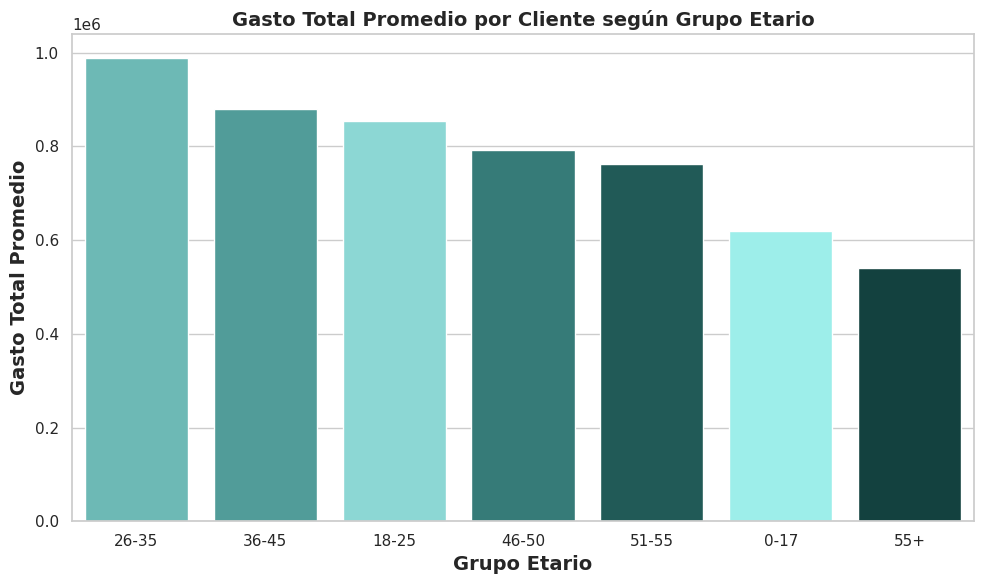

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=gasto_por_edad.index, y=gasto_por_edad.values, palette=palette_age, hue=gasto_por_edad.index, legend=False)
plt.title('Gasto Total Promedio por Cliente según Grupo Etario', fontsize=14, fontweight="bold")
plt.xlabel('Grupo Etario', fontsize=14, fontweight="bold")
plt.ylabel('Gasto Total Promedio', fontsize=14, fontweight="bold")
plt.xticks()
plt.tight_layout()
plt.show()

El gasto total promedio por cliente más alto aparece en 26-35, seguido por 36 - 45 y 18 - 25.


#### 3) ¿Dónde se encuentra el mayor número de clientes?


En el punto 2.b se respondió esta pregunta: la ciudad C concentra la mayor cantidad de clientes (53.3%), seguida por B (29.0%) y A (17.7%). En ese mismo punto se analizó también la relación entre `City_Category` y la cantidad de transacciones, mostrando que A y B, pese a tener menos clientes, transaccionan con mayor frecuencia por cliente.


#### 4) ¿Cuántos productos únicos tiene el dataset?


In [ ]:
print(f"Productos únicos (Product_ID): {df['Product_ID'].nunique():,}")


Productos únicos (Product_ID): 3,631


Hay **3.631 productos únicos**, sobre un total de 550.068 transacciones y 5.891 clientes.


#### 5) ¿Cuáles son las categorías de productos más frecuentes?


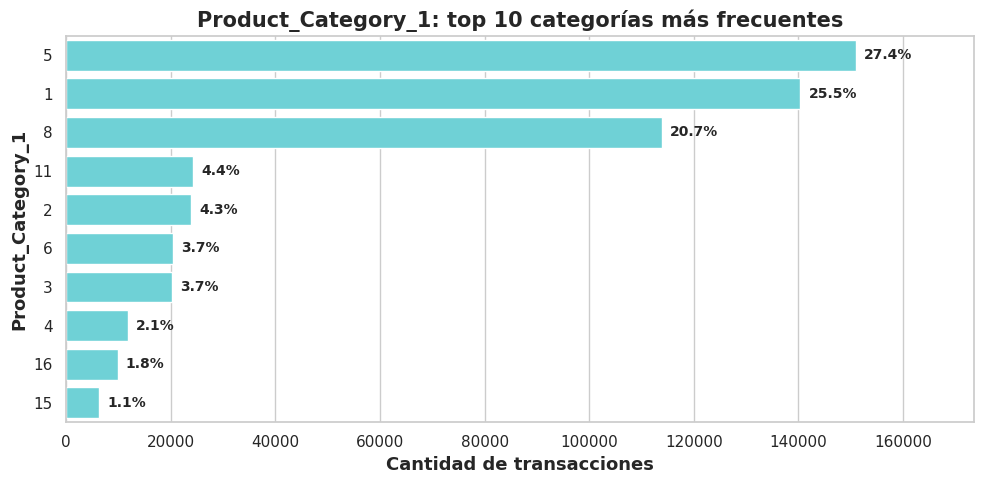

In [ ]:
top_cat1 = df['Product_Category_1'].value_counts().head(10)

total_transacciones = len(df)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(y=top_cat1.index.astype(str), x=top_cat1.values, color='#5ee0e7',
            order=top_cat1.index.astype(str), ax=ax)

ax.set_title('Product_Category_1: top 10 categorías más frecuentes', fontsize=15, fontweight='bold')
ax.set_xlabel('Cantidad de transacciones', fontsize=13, fontweight='bold')
ax.set_ylabel('Product_Category_1', fontsize=13, fontweight='bold')
ax.tick_params(axis='both', labelsize=11)

for p in ax.patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_transacciones) * 100:.1f}%'
    ax.annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(6, 0), textcoords='offset points',
        fontsize=10, fontweight='bold',
    )
ax.set_xlim(0, top_cat1.values.max() * 1.15)

plt.tight_layout()
plt.show()

Las más frecuentes son **5, 1 y 8**, representando en conjunto un 73.6% de las transacciones.


#### 6) ¿Qué combinaciones de categorías están asociadas a un mayor gasto?


,cantidad,gasto_medio
combo,,
10 | 13 | NA,860,"20,789.91"
10 | 15 | NA,982,"20,141.14"
10 | 16 | NA,1071,"19,704.60"
15 | 17 | NA,737,"18,951.67"
10 | 13 | 16,1020,"18,616.61"
6 | 10 | 13,1581,"16,870.53"
7 | NA | NA,3421,"16,502.64"
6 | 10 | 16,618,"16,189.74"
6 | 8 | NA,6457,"16,127.25"


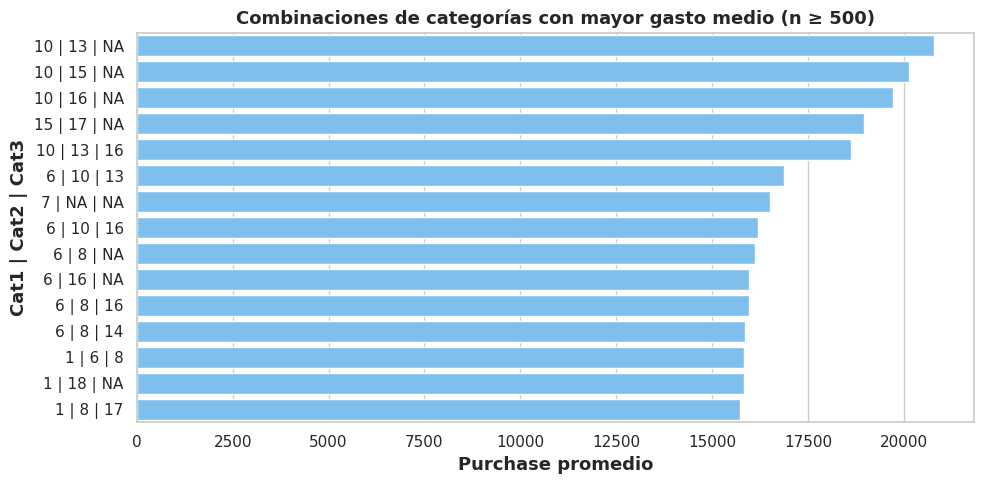

In [ ]:
df_combo = df.copy()
df_combo['Cat2'] = df_combo['Product_Category_2'].fillna('NA').astype(str).str.replace('.0', '', regex=False)
df_combo['Cat3'] = df_combo['Product_Category_3'].fillna('NA').astype(str).str.replace('.0', '', regex=False)
df_combo['combo'] = (
    df_combo['Product_Category_1'].astype(str) + ' | ' +
    df_combo['Cat2'] + ' | ' +
    df_combo['Cat3']
)

combo_stats = (
    df_combo.groupby('combo')
    .agg(cantidad=('Purchase', 'count'), gasto_medio=('Purchase', 'mean'))
    .query('cantidad >= 500')  # evitamos combinaciones raras con pocas ventas
    .sort_values('gasto_medio', ascending=False)
    .head(15)
)
display(combo_stats)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(y=combo_stats.index, x=combo_stats['gasto_medio'], color='#6dc2ff', ax=ax)
ax.set_title('Combinaciones de categorías con mayor gasto medio (n ≥ 500)',  fontsize=13, fontweight='bold')
ax.set_xlabel('Purchase promedio',  fontsize=13, fontweight='bold')
ax.set_ylabel('Cat1 | Cat2 | Cat3',  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Combinaciones con **categoría 10** (y a veces 15, 6, 7) muestran facturaciones medias muy altas (~16–20 mil). No son las más vendidas, pero sí las más "caras" en promedio.


#### 7) ¿Cuáles son los productos con mayor monto de compra?


In [ ]:
# Por monto total acumulado y por factura media
top_sum = (
    df.groupby('Product_ID')['Purchase']
    .agg(monto_total='sum', fact_media='mean', ventas='count')
    .sort_values('monto_total', ascending=False)
    .head(10)
)
print('Top 10 productos por monto TOTAL:')
display(top_sum)

top_mean = (
    df.groupby('Product_ID')['Purchase']
    .agg(fact_media='mean', ventas='count', monto_total='sum')
    .query('ventas >= 50')
    .sort_values('fact_media', ascending=False)
    .head(10)
)
print('Top 10 productos por facturacion media (con al menos 50 ventas):')
display(top_mean)


Top 10 productos por monto TOTAL:


,monto_total,fact_media,ventas
Product_ID,,,
P00025442,27995166,"17,334.47",1615
P00110742,26722309,"16,577.11",1612
P00255842,25168963,"18,198.82",1383
P00059442,24338343,"17,310.34",1406
P00184942,24334887,"16,899.23",1440
P00112142,24216006,"15,503.20",1562
P00110942,23639564,"17,382.03",1360
P00237542,23425576,"16,804.57",1394
P00057642,23102780,"15,716.18",1470


Top 10 productos por facturacion media (con al menos 50 ventas):


,fact_media,ventas,monto_total
Product_ID,,,
P00086242,"21,256.51",273,5803026
P00085342,"20,980.27",552,11581108
P00200642,"20,468.77",269,5506100
P00116142,"20,463.79",642,13137754
P00119342,"20,448.76",308,6298217
P00117642,"20,400.28",395,8058112
P00052842,"20,141.14",982,19778599
P00087042,"20,113.22",240,4827174
P00202242,"19,992.04",122,2439029


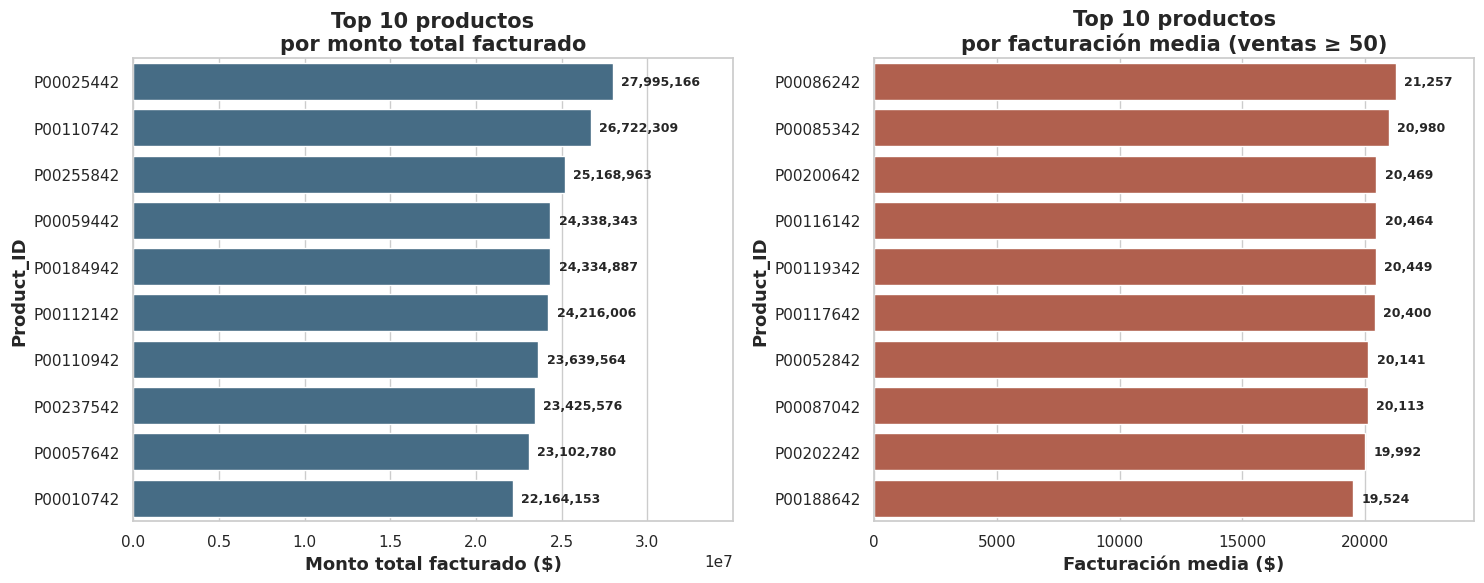

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Top por monto total
sns.barplot(y=top_sum.index, x=top_sum['monto_total'], color='#3B6E8F', ax=axes[0])
axes[0].set_title('Top 10 productos\npor monto total facturado', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Monto total facturado ($)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Product_ID', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=11)

for p in axes[0].patches:
    ancho = p.get_width()
    axes[0].annotate(
        f'{ancho:,.0f}', (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(6, 0), textcoords='offset points',
        fontsize=9, fontweight='bold',
    )
axes[0].set_xlim(0, top_sum['monto_total'].max() * 1.25)

# Panel 2: Top por facturación media
sns.barplot(y=top_mean.index, x=top_mean['fact_media'], color='#C0563E', ax=axes[1])
axes[1].set_title('Top 10 productos\npor facturación media (ventas ≥ 50)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Facturación media ($)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Product_ID', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=11)

for p in axes[1].patches:
    ancho = p.get_width()
    axes[1].annotate(
        f'{ancho:,.0f}', (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(6, 0), textcoords='offset points',
        fontsize=9, fontweight='bold',
    )
axes[1].set_xlim(0, top_mean['fact_media'].max() * 1.15)

plt.tight_layout()
plt.show()

**Respuesta:** Productos como `P00025442`, `P00110742`, `P00255842` lideran por **monto total**. El ranking por factura media puede cambiar: un producto "caro" no siempre es el más vendido.


#### 8 y 9) Clientes/gasto con faltantes en `Product_Category_2` y `Product_Category_3`


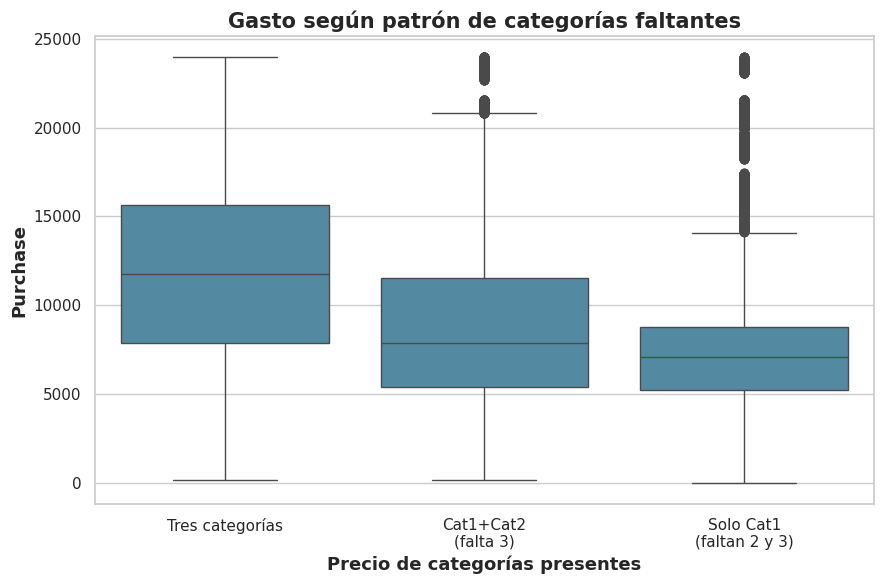

In [ ]:
c2_na = df['Product_Category_2'].isna()
c3_na = df['Product_Category_3'].isna()
df['patron_faltantes'] = np.select(
    [c2_na & c3_na, (~c2_na) & c3_na, (~c2_na) & (~c3_na)],
    ['Solo Cat1\n(faltan 2 y 3)', 'Cat1+Cat2\n(falta 3)', 'Tres categorías'],
    default='Otro'
)

orden_faltantes = ['Tres categorías', 'Cat1+Cat2\n(falta 3)', 'Solo Cat1\n(faltan 2 y 3)']

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df, x='patron_faltantes', y='Purchase',
            order=orden_faltantes, color='#468faf', ax=ax)
ax.set_title('Gasto según patrón de categorías faltantes', fontsize=15, fontweight='bold')
ax.set_xlabel('Precio de categorías presentes', fontsize=13, fontweight='bold')
ax.set_ylabel('Purchase', fontsize=13, fontweight='bold')
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()


**Respuesta (8 y 9):** Cuando el producto tiene **las 3 categorías**, el gasto medio es claramente mayor (11.6 mil). Si faltan Cat2 y Cat3 (solo Cat1), el gasto baja (7.5 mil).
 Los faltantes están asociados a tipos de producto con distinto precio/gasto. En un modelo, conviene tratarlos (definimos marcarlos en 0 en lugar de borrar filas ).


### 2.e Relación entre variables y la variable objetivo


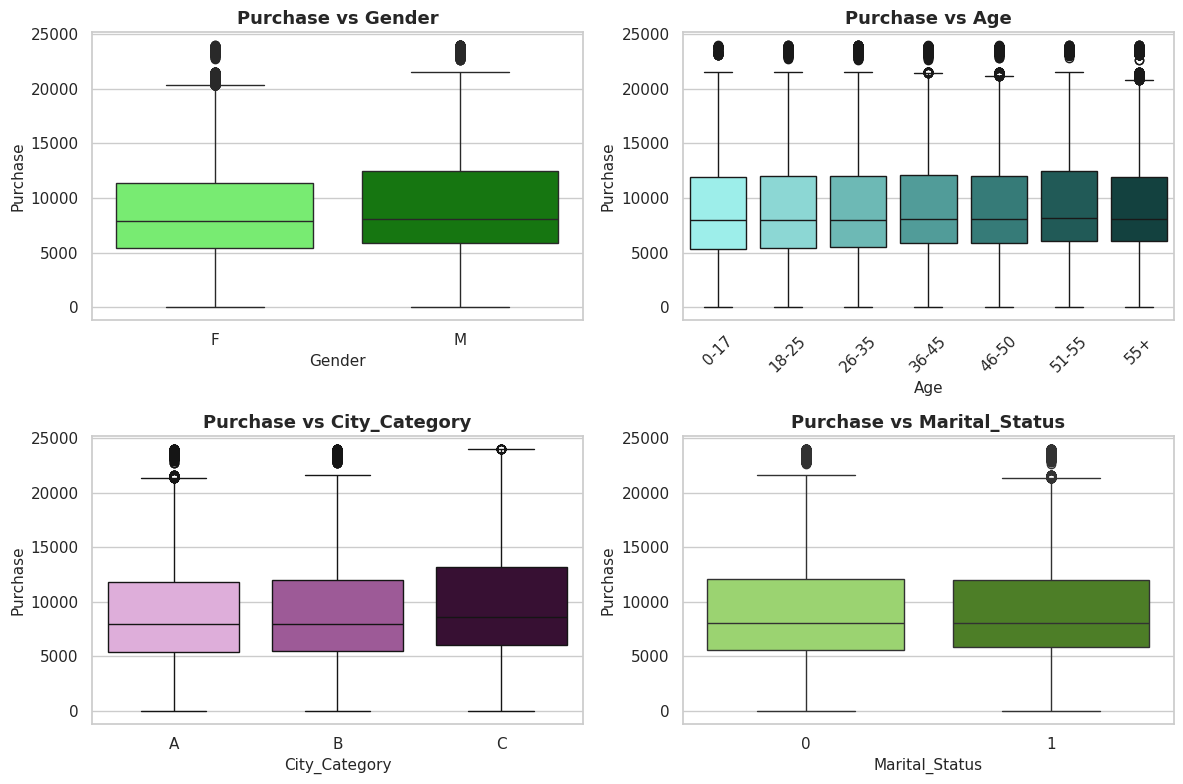

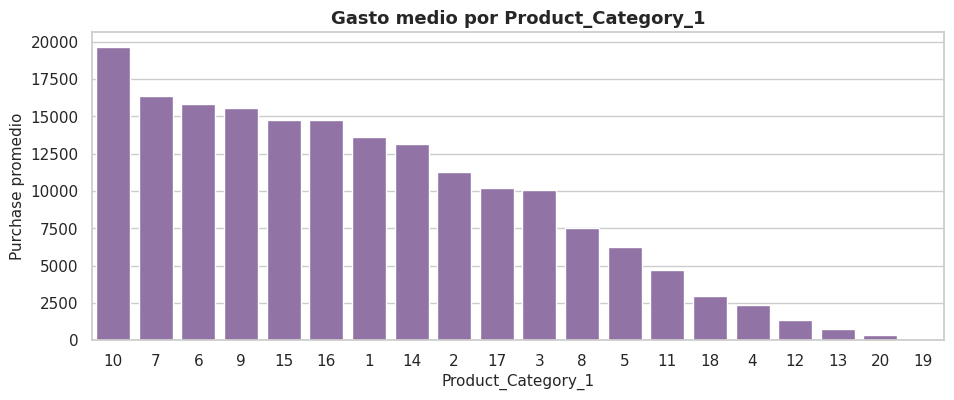

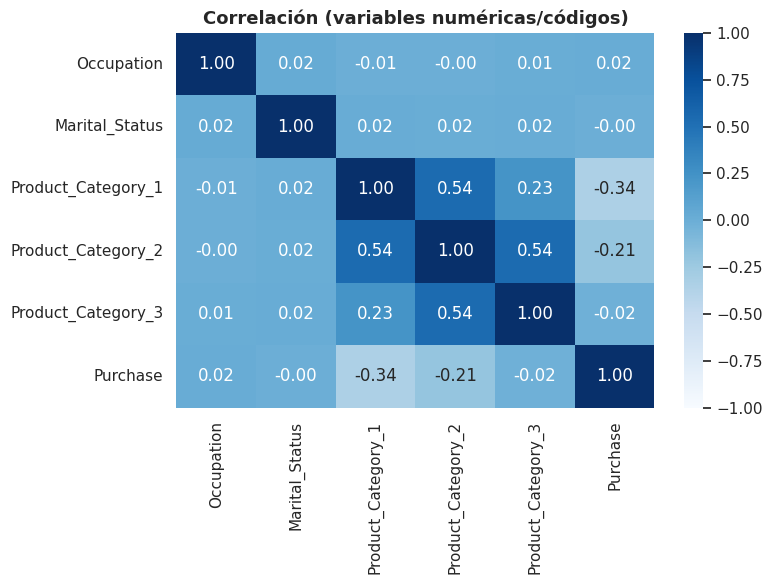

In [ ]:
age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x='Gender', y='Purchase', order=['F', 'M'],
            hue='Gender', palette=palette_gender, legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Purchase vs Gender', fontweight='bold')

sns.boxplot(data=df, x='Age', y='Purchase', order=age_order,
            hue='Age', palette=palette_age, legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Purchase vs Age', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='City_Category', y='Purchase', order=['A', 'B', 'C'],
            hue='City_Category', palette=palette_city, legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Purchase vs City_Category', fontweight='bold')

sns.boxplot(data=df, x='Marital_Status', y='Purchase',
            hue='Marital_Status', palette=palette_marital, legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Purchase vs Marital_Status', fontweight='bold')

plt.tight_layout()
plt.show()

print()

# Product_Category_1 -> color plano (mismo criterio que Occupation: sin orden real)
cat1_purchase = df.groupby('Product_Category_1')['Purchase'].mean().sort_values(ascending=False)
codigos_cat1 = cat1_purchase.index.astype(str)
palette_cat1 = {c: '#946BAE' for c in codigos_cat1}

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(x=codigos_cat1, y=cat1_purchase.values, hue=codigos_cat1,
            palette=palette_cat1, legend=False, order=codigos_cat1, ax=ax)
ax.set_title('Gasto medio por Product_Category_1', fontweight='bold')
ax.set_xlabel('Product_Category_1')
ax.set_ylabel('Purchase promedio')
plt.show()

print()

corr = df[['Occupation', 'Marital_Status', 'Product_Category_1',
             'Product_Category_2', 'Product_Category_3', 'Purchase']].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlación (variables numéricas/códigos)', fontweight='bold')
plt.tight_layout()
plt.show()

- **Purchase vs Gender:** hay menos mujeres que hacen compras mas caras porque el bigote está más abajo.
- **Purchase vs Age:** es menos frecuente que las personas del grupo etario +55 hagan compras caras. En promedio, todos los grupos etarios gastan mas o menos lo mismo.
- **Purchase vs City:** La ciudad C parece ser la que más gasta.
- **Purchase vs Marital_Status:** No hay una diferencia clara entre los grupos de clientes entre casados y no casados.




Las categorias que representan mayos gasto son la 10, 7 y 6.

Las diferencias demográficas existen pero son **moderadas**. La señal más fuerte para el gasto está en las **categorías de producto** (sobre todo `Product_Category_1`). Género, edad y ciudad aportan contexto; estado civil y ocupacion presentan una relacion casi nula con `Purchase`.


### 2.f Segmentación del gasto (bajo / medio / alto)


In [ ]:
# Segmentamos Purchase en terciles (33% / 33% / 33%)
df['Segmento_Gasto'] = pd.qcut(df['Purchase'], q=3, labels=['Bajo', 'Medio', 'Alto'])

seg = df.groupby('Segmento_Gasto', observed=True)['Purchase'].agg(
    n='count', minimo='min', media='mean', mediana='median', maximo='max'
)
display(seg)

# Caracterización de cada segmento
print('Género (% dentro del segmento):')
display(pd.crosstab(df['Segmento_Gasto'], df['Gender'], normalize='index').round(3))

print('Ciudad (% dentro del segmento):')
display(pd.crosstab(df['Segmento_Gasto'], df['City_Category'], normalize='index').round(3))

print('Top categorías en cada segmento:')
for seg_name in ['Bajo', 'Medio', 'Alto']:
    top = df.loc[df['Segmento_Gasto'] == seg_name, 'Product_Category_1'].value_counts(normalize=True).head(3)
    print(f'  {seg_name}:', {int(k): round(v, 3) for k, v in top.items()})


,n,minimo,media,mediana,maximo
Segmento_Gasto,,,,,
Bajo,183428,12,"4,287.23","4,597.00",6915
Medio,183325,6916,"8,254.45","8,047.00",10068
Alto,183315,10069,"15,253.35","15,460.00",23961


Género (% dentro del segmento):


Gender,F,M
Segmento_Gasto,,
Bajo,0.26,0.74
Medio,0.27,0.73
Alto,0.20,0.80


Ciudad (% dentro del segmento):


City_Category,A,B,C
Segmento_Gasto,,,
Bajo,0.29,0.43,0.28
Medio,0.27,0.41,0.32
Alto,0.25,0.41,0.34


Top categorías en cada segmento:
  Bajo: {5: 0.415, 8: 0.22, 11: 0.114}
  Medio: {5: 0.409, 8: 0.396, 1: 0.093}
  Alto: {1: 0.623, 6: 0.101, 2: 0.072}


- **porcentaje de mujeres y hombres en cada segmento:** se observa, nuevamente, que la proporción de mujeres es menor en el segmento alto (20,3%) que en el bajo (26,4%).
- **porcentaje por ciudad:** en cada uno de los segmentos, las ciudades no se comportan diferente a como se comportan en el total.

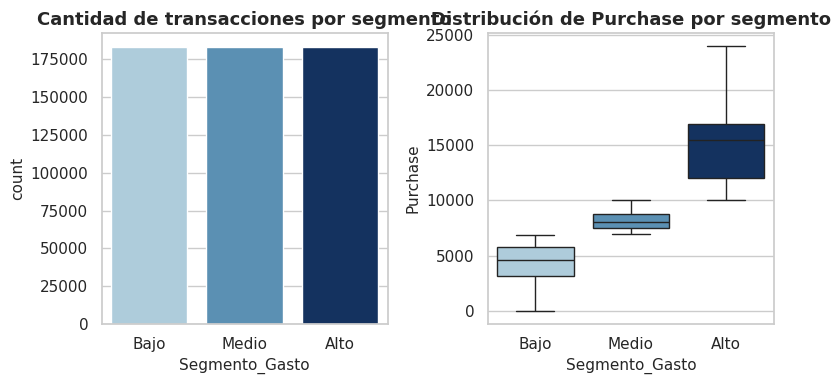

In [ ]:
df['Segmento_Gasto'] = pd.qcut(df['Purchase'], q=3, labels=['Bajo', 'Medio', 'Alto'])

palette_segmento = {'Bajo': '#a6cee3', 'Medio': '#4c93c2', 'Alto': '#08306b'}

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.countplot(data=df, x='Segmento_Gasto', hue='Segmento_Gasto',
              order=['Bajo', 'Medio', 'Alto'], palette=palette_segmento, legend=False, ax=axes[0])
axes[0].set_title('Cantidad de transacciones por segmento', fontweight='bold')

sns.boxplot(data=df, x='Segmento_Gasto', y='Purchase', hue='Segmento_Gasto',
            order=['Bajo', 'Medio', 'Alto'], palette=palette_segmento, legend=False, ax=axes[1])
axes[1].set_title('Distribución de Purchase por segmento', fontweight='bold')
plt.tight_layout()
plt.show()


**perfil de segmentos**

| Segmento | Ticket aproximado | Característica principales |
|----------|-------------------|--------------------------|
| **Bajo** | ~4.3 mil promedio | Mucho peso de categorías 5 y 8 |
| **Medio** | ~8.3 mil promedio | Mezcla; aún fuerte presencia de 5 y 8 |
| **Alto** | ~15.3 mil promedio | Dominado por categoría **1**; más hombres y más ciudad C |

Los tres segmentos tienen un tamaño casi idéntico (~183 mil transacciones cada uno, por construcción
de los terciles). Se distinguen mucho más por tipo de producto (`Product_Category_1`) que por variables
demográficas, consistente con lo ya observado en 2.e: la categoría de producto es la variable con mayor
poder explicativo sobre el gasto.

### 2.g Selección preliminar de variables para un futuro modelo


In [ ]:
# ranking simple: que tanto cambia el gasto medio entre grupos de cada variable
def dispersion_entre_grupos(col):
    medias = df.groupby(col)['Purchase'].mean()
    return medias.max() - medias.min()

candidatas = [
    'Gender', 'Age', 'Occupation', 'City_Category',
    'Stay_In_Current_City_Years', 'Marital_Status',
    'Product_Category_1', 'Product_Category_2', 'Product_Category_3',
    'Product_ID'
]

ranking = (
    pd.Series({c: dispersion_entre_grupos(c) for c in candidatas})
    .sort_values(ascending=False)
    .to_frame('rango_gasto_medio (max-min)')
)
display(ranking)


,rango_gasto_medio (max-min)
Product_ID,"21,219.83"
Product_Category_1,"19,638.53"
Product_Category_2,"8,764.05"
Product_Category_3,"5,224.18"
Occupation,"1,183.73"
City_Category,807.98
Gender,702.96
Age,601.34
Stay_In_Current_City_Years,140.35
Marital_Status,4.73


**variables interesantes para el modelo**

**Incluir con alta prioridad**
- `Product_Category_1` (y 2/3, con tratamiento de nulos)
- `Product_ID` (muy informativo, aunque con muchos niveles)
- `Occupation`, `Age`, `City_Category`, `Gender`

**Incluir con menor prioridad / revisar**
- `Stay_In_Current_City_Years`
- `Marital_Status` (poca diferencia de gasto)

**No usar como predictor "crudo"**
- `User_ID` (identificador; puede servir para agregados históricos, no como categoría suelta sin cuidado)
- `Purchase` (es el objetivo)




---
## Resumen

1. Dataset grande (~550k filas), 5.891 clientes, 3.631 productos.
2. No hay fechas → análisis transversal, no temporal.
3. Nulos relevantes solo en categorías 2 y 3; tienen sentido de negocio y se asocian al nivel de gasto.
4. Objetivo: `Purchase` (regresión supervisada).
5. El gasto depende sobre todo del **producto/categoría**; la demografía aporta matices.
6. Segmentos bajo/medio/alto se separan claramente por categoría de producto.
